<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº9
#### Joaquin Gomez Lucero y Milena Waichman Scigliano


# Introduccion

El electrocardiograma (ECG) es una de las señales biomédicas más utilizadas para evaluar la actividad eléctrica del corazón. Sin embargo, en condiciones reales de registro, especialmente durante una prueba de esfuerzo, la señal se ve afectada por diversas fuentes de contaminación que dificultan su análisis. Entre las interferencias más relevantes se encuentran el ruido producido por el movimiento de los electrodos y el ruido muscular, ambos de alta frecuencia, y la deriva de la línea de base, asociada principalmente a la respiración y a movimientos de baja frecuencia. Estas perturbaciones pueden enmascarar las ondas características del ECG e impedir que la señal se asemeje a un trazado clínicamente útil, con trazos suaves y nivel isoeléctrico bien definido.

A diferencia de los filtros lineales clásicos utilizados en tareas previas, esta práctica se enfoca en métodos no lineales aplicados directamente sobre el ECG para la eliminación de artefactos y la detección robusta de QRS. En particular, se analizan tres técnicas ampliamente empleadas en procesamiento de señales biomédicas:
- Filtro de mediana, capaz de suprimir variaciones lentas sin distorsionar la forma del QRS.
- Corrección de la línea de base mediante spline cúbico, que interpola puntos estables para reconstruir un nivel isoeléctrico suave y continuo.
- Filtro adaptado (matched filter), basado en correlación con una plantilla que modela la forma típica del complejo QRS.

Cada método se aplica sobre un ECG real provisto por la cátedra (ECG_TP4.mat) y se evalúa su desempeño tanto en la eliminación de artefactos como en la preservación de la información fisiológica relevante.

En esta tarea semanal se analizarán técnicas no lineales de estimación/substracción de la señal de movimiento de base b(n).
$$ \hat{x} = s - \hat{b} $$
Siendo *s* la señal de ECG registrada **con interferencias**, y $\hat{x}$ la señal filtrada, una estimación del ECG **sin interferencias**. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.io as sio
from scipy.interpolate import CubicSpline

##################
# Lectura de ECG #
##################
fs_ecg = 1000 # Hz

# para listar las variables que hay en el archivo
#io.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)


## Eliminación de la línea de base mediante filtro de mediana

La señal de ECG suele presentar una deriva lenta del nivel isoeléctrico, causada principalmente por movimientos respiratorios y variaciones de impedancia. Esta deriva se concentra en frecuencias menores a aproximadamente $0.5$ Hz. Una forma eficaz de corregirla es estimar dicha componente lenta y restarla del registro.
El filtro de mediana es una herramienta no lineal especialmente adecuada para esta tarea. A diferencia de un filtro lineal pasabajos, la mediana no promedia sino que selecciona el valor central de una ventana deslizante. Esto le permite eliminar variaciones lentas sin suavizar o distorsionar los picos abruptos del complejo QRS, cuya morfología debe preservarse.
 
En esta práctica se aplicaron dos medianas en cascada:
- Ventana de 200 muestras → atenúa oscilaciones intermedias (movimientos suaves).
- Ventana de 600 muestras → extrae únicamente la componente de muy baja frecuencia vinculada a la respiración.

$$ \hat{b} = \underset{\text{600}}{\text{med}} ( \underset{\text{200}}{\text{med}} (s)) $$
siendo $\underset{\text{t}}{\text{med}}(s)$ el operador de mediana de t milisegundos que se aplica sobre la señal s:
$$ \hat{b} = med(m[n],m[n-1],...,m[n-600])$$
donde 
$$ m[n] = med(s[n],s[n-1],...,s[n-200])$$
El resultado de esta doble filtración constituye una estimación efectiva de la línea de base. Restando dicha estimación del ECG original se obtiene una señal corregida, donde el nivel isoeléctrico se mantiene estable y la morfología del complejo QRS queda preservada.

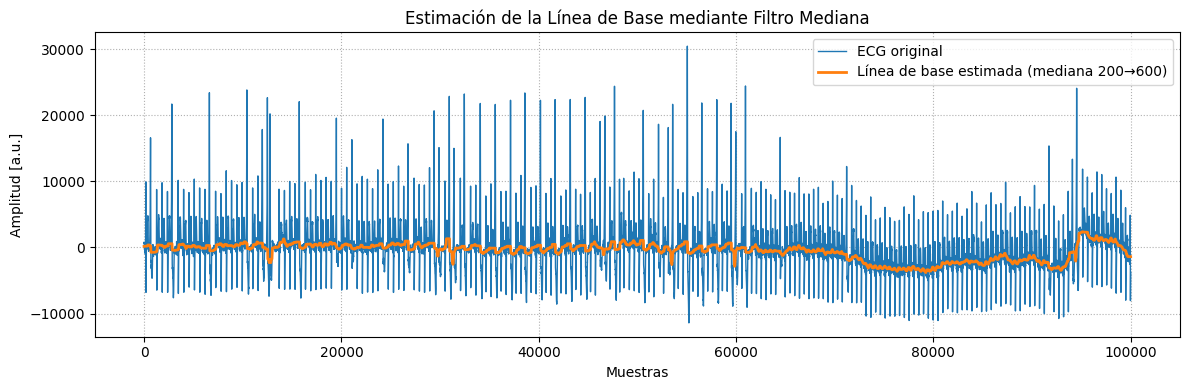

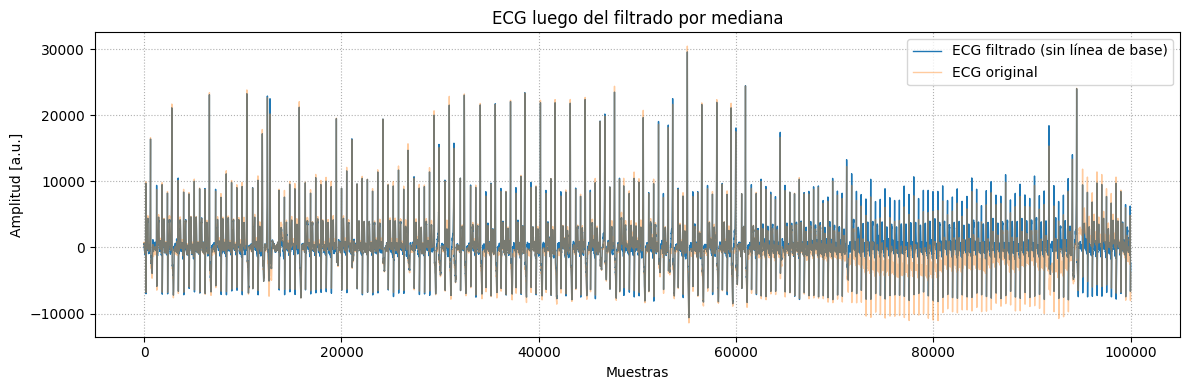

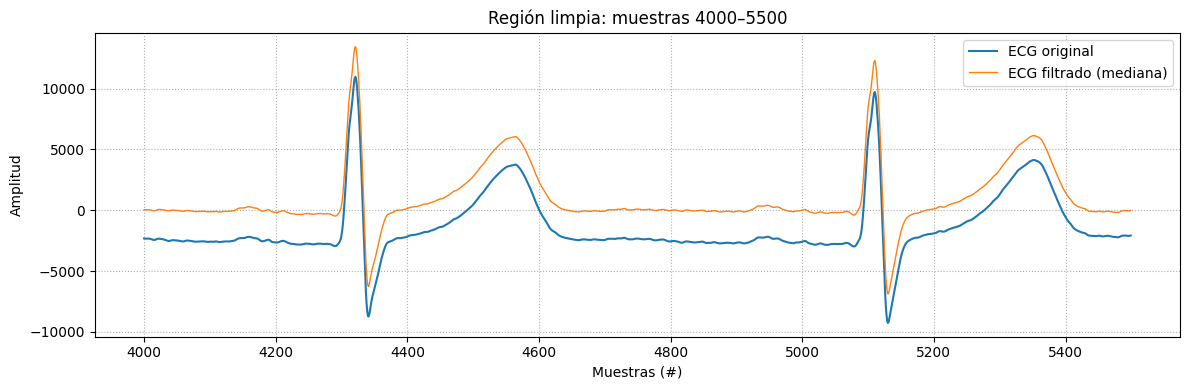

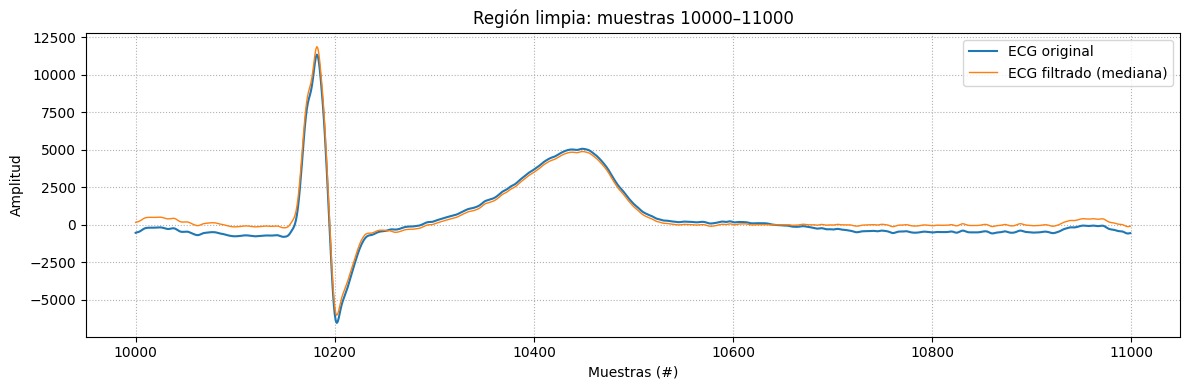

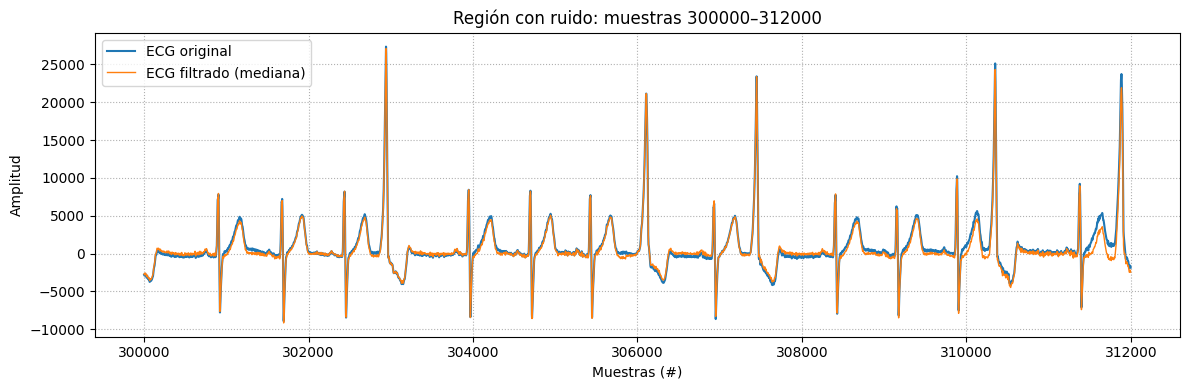

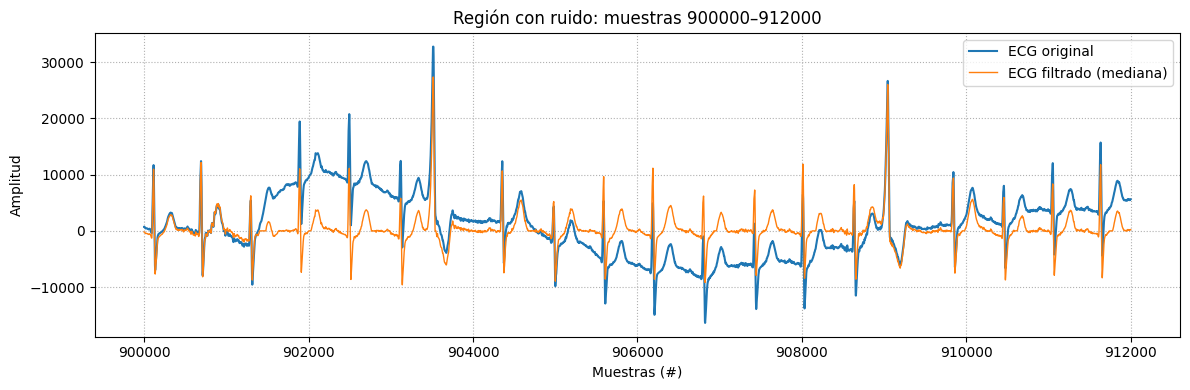

In [11]:

# Ventanas de mediana
mediana_200 = signal.medfilt(ecg_one_lead, 199)
mediana_600 = signal.medfilt(mediana_200, 599)

# Señal sin la línea de base
ecg_mediana = ecg_one_lead - mediana_600

###################################
# Gráfico 1: Señal + línea de base
###################################
plt.figure(figsize=(12,4))
plt.plot(ecg_one_lead[500000:600000], label='ECG original', linewidth=1)
plt.plot(mediana_600[500000:600000], label='Línea de base estimada (mediana 200→600)', linewidth=2)
plt.title('Estimación de la Línea de Base mediante Filtro Mediana')
plt.xlabel('Muestras')
plt.ylabel('Amplitud [a.u.]')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()

###################################
# Gráfico 2: Señal corregida
###################################
plt.figure(figsize=(12,4))
plt.plot(ecg_mediana[500000:600000], label='ECG filtrado (sin línea de base)', linewidth=1)
plt.plot(ecg_one_lead[500000:600000], alpha=0.4, label='ECG original', linewidth=1)
plt.title('ECG luego del filtrado por mediana')
plt.xlabel('Muestras')
plt.ylabel('Amplitud [a.u.]')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()

plt.show()

##########################################
# Regiones de interés sin ruido claro
##########################################

regs_interes = [4000, 5500],[10_000, 11_000]

for ini, fin in regs_interes:
    zoom = np.arange(ini, fin, dtype='uint')
    
    plt.figure(figsize=(12,4))
    plt.plot(zoom, ecg_one_lead[zoom], label='ECG original', linewidth=1.5)
    plt.plot(zoom, ecg_mediana[zoom], label='ECG filtrado (mediana)', linewidth=1)
    plt.title(f'Región limpia: muestras {ini}–{fin}')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Amplitud')
    plt.grid(True, ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()


##########################################
# Regiones con ruido
##########################################

regs_interes_ruido = [
    (np.array([5, 5.2]) * 60 * fs_ecg),
    (np.array([15, 15.2]) * 60 * fs_ecg)
]

for ventana in regs_interes_ruido:
    ini, fin = ventana.astype(int)
    zoom = np.arange(ini, fin, dtype='uint')

    plt.figure(figsize=(12,4))
    plt.plot(zoom, ecg_one_lead[zoom], label='ECG original', linewidth=1.5)
    plt.plot(zoom, ecg_mediana[zoom], label='ECG filtrado (mediana)', linewidth=1)
    plt.title(f'Región con ruido: muestras {ini}–{fin}')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Amplitud')
    plt.grid(True, ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Corrección de la línea de base mediante spline cúbico

Además del filtrado por mediana, otra estrategia frecuente para eliminar la deriva lenta del ECG consiste en reconstruir explícitamente la línea de base mediante interpolación. La idea es seleccionar puntos de la señal donde se sabe que el ECG se encuentra en un estado relativamente estable y cercano al nivel isoeléctrico, y utilizar esos valores como nodos para generar una curva suave que represente la componente de baja frecuencia.
En esta práctica se empleó un spline cúbico, una función compuesta por segmentos polinomiales de tercer grado que garantiza continuidad en la señal, su derivada y su segunda derivada. Esta suavidad es adecuada para modelar la variación lenta de la línea de base sin introducir oscilaciones artificiales.

#### Selección de nodos
Los nodos para el spline se obtuvieron a partir de las detecciones de QRS provistas por el docente. Para cada máximo $R$ se eligió:
$$ n_{nodo} = R - 80$$
Este desplazamiento sitúa el nodo aproximadamente en el segmento PQ, es el momento más adecuado para estimar las características de la interferencia que originan el movimiento de la línea de base. Ese intervalo corresponde al segmento PQ, donde la actividad eléctrica es estable y de baja variación.

Esto resultará en un conjunto de valores 
$$ S = {n_{nodo}, s(n_{nodo}) | i = 1,2,...,Q} $$

$$ \hat{b}(n) = spline_3(S,n) | n = 1,2,...,N $$

donde la función $spline_3$ será la responsable de realizar la interpolación para las *N* muestras de la señal s.

En comparación con el filtro de mediana, el spline produce una estimación más suave y continua, ajustándose mejor a la evolución lenta del nivel isoeléctrico.

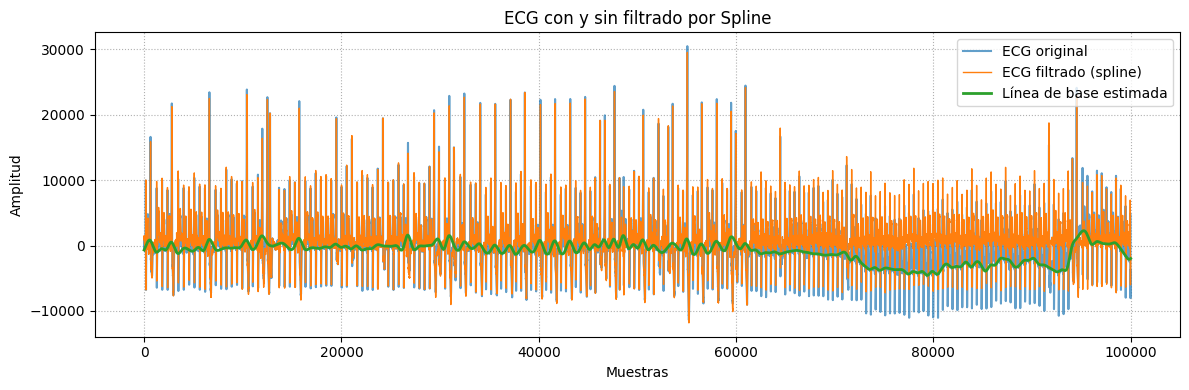

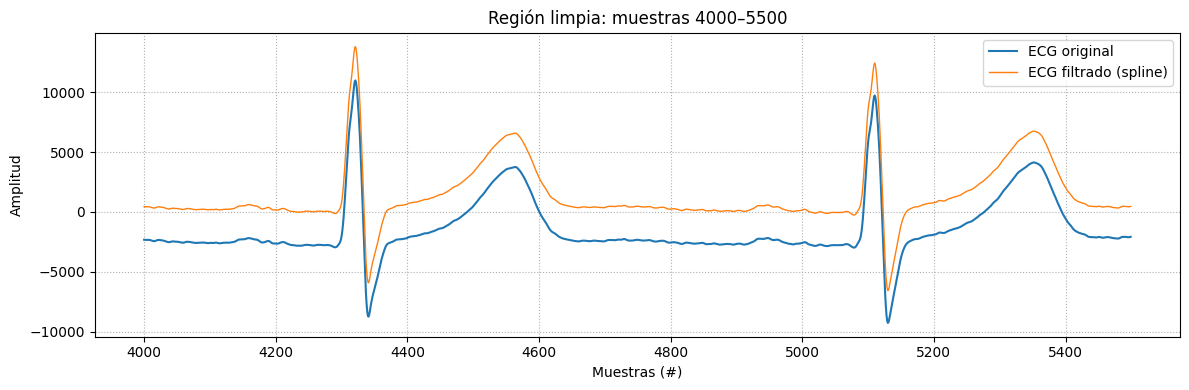

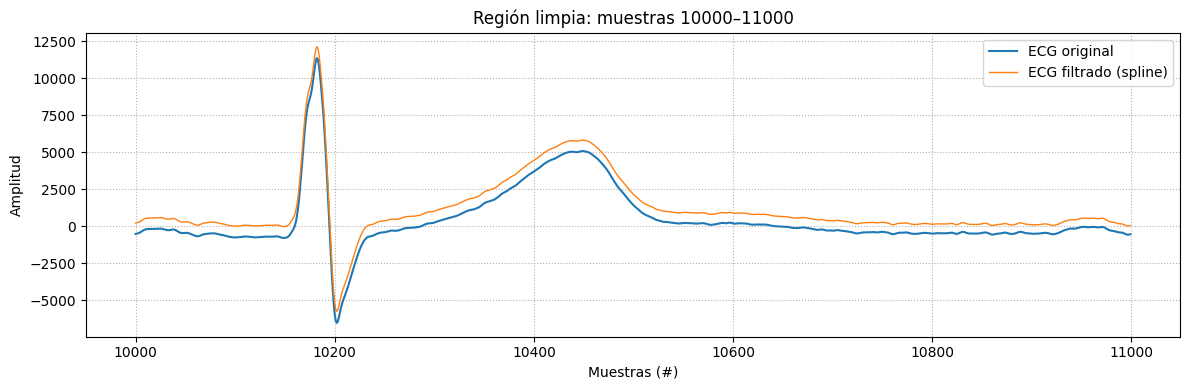

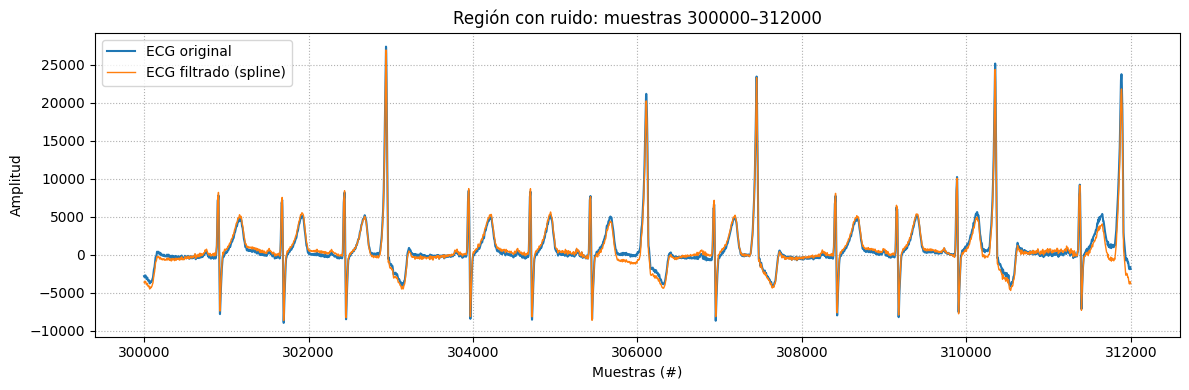

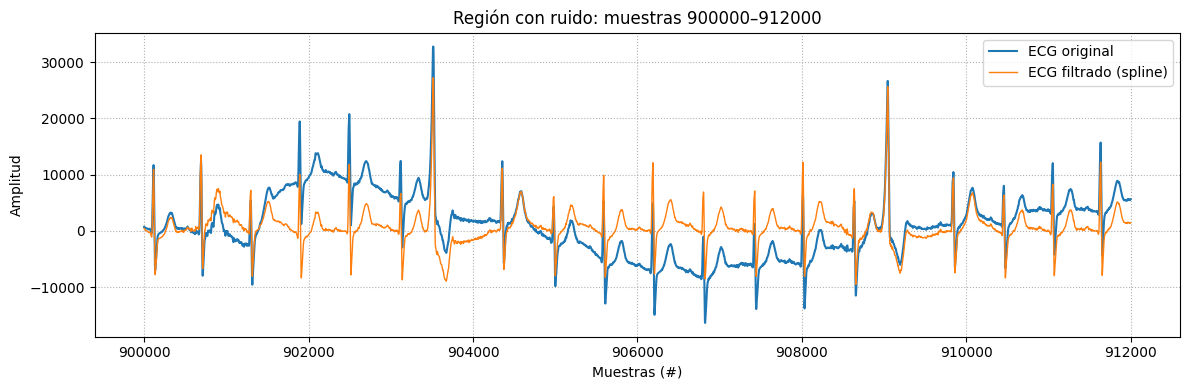

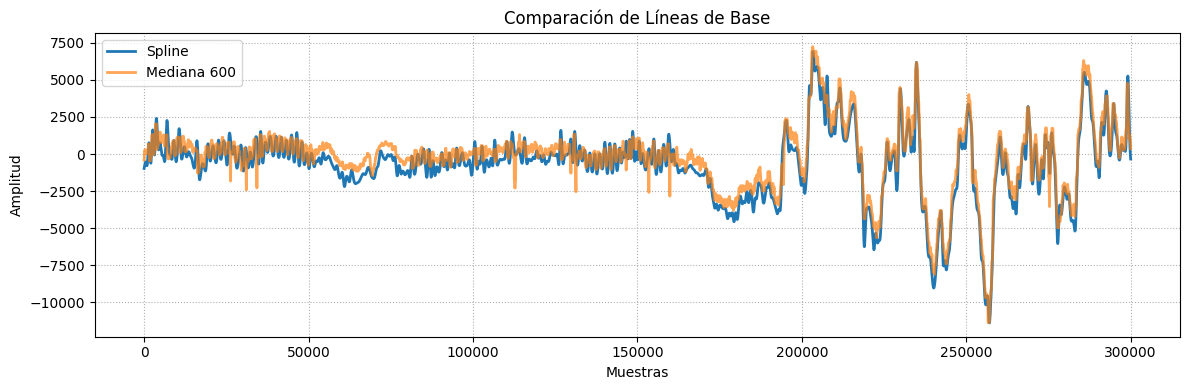

In [12]:

#################################
# Eliminación de línea de base  #
# mediante Spline Cúbico        #
#################################

maximos = mat_struct['qrs_detections'].flatten()
muestras = np.arange(N)

# Nodos para el spline: un poco antes del R (donde la señal es más estable)
nodos = maximos - 80
nodos = nodos[nodos > 0]  # evitar índices negativos

# Spline sobre los nodos
spl = CubicSpline(nodos, ecg_one_lead[nodos])
baseline_spline = spl(np.arange(N))

# Señal corregida
ecg_spline = ecg_one_lead - baseline_spline


########################
# Gráfico general
########################

plt.figure(figsize=(12,4))
plt.plot(ecg_one_lead[500000:600000], label='ECG original', alpha=0.7)
plt.plot(ecg_spline[500000:600000], label='ECG filtrado (spline)', linewidth=1)
plt.plot(baseline_spline[500000:600000], label='Línea de base estimada', linewidth=2)
plt.title('ECG con y sin filtrado por Spline')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()


##########################################
# Regiones de interés sin ruido claro
##########################################

regs_interes = [4000, 5500],[10_000, 11_000]

for ini, fin in regs_interes:
    zoom = np.arange(ini, fin, dtype='uint')
    
    plt.figure(figsize=(12,4))
    plt.plot(zoom, ecg_one_lead[zoom], label='ECG original', linewidth=1.5)
    plt.plot(zoom, ecg_spline[zoom], label='ECG filtrado (spline)', linewidth=1)
    plt.title(f'Región limpia: muestras {ini}–{fin}')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Amplitud')
    plt.grid(True, ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()


##########################################
# Regiones con ruido
##########################################

regs_interes_ruido = [
    (np.array([5, 5.2]) * 60 * fs_ecg),
    (np.array([15, 15.2]) * 60 * fs_ecg),
]

for ventana in regs_interes_ruido:
    ini, fin = ventana.astype(int)
    zoom = np.arange(ini, fin, dtype='uint')

    plt.figure(figsize=(12,4))
    plt.plot(zoom, ecg_one_lead[zoom], label='ECG original', linewidth=1.5)
    plt.plot(zoom, ecg_spline[zoom], label='ECG filtrado (spline)', linewidth=1)
    plt.title(f'Región con ruido: muestras {ini}–{fin}')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Amplitud')
    plt.grid(True, ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()


###########################
# Comparación baseline vs mediana
###########################

plt.figure(figsize=(12,4))
plt.plot(baseline_spline[400000:700000], label='Spline', linewidth=2)
plt.plot(mediana_600[400000:700000], label='Mediana 600', linewidth=2, alpha=0.7)
plt.title('Comparación de Líneas de Base')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()




## Detección de complejos QRS mediante filtro adaptado (Matched Filter)

La identificación precisa de los complejos QRS es una de las tareas centrales en el análisis de señales de ECG. Para detectar estos, se empleó un filtro adaptado (matched filter), una herramienta clásica en procesamiento de señales que maximiza la relación señal-ruido cuando se conoce la forma aproximada del pulso a detectar. El concepto es simple: si se dispone de una plantilla que representa la forma típica del QRS, su correlación con la señal amplifica aquellos segmentos que se asemejan a dicha plantilla y atenúa los que no.

Para construir la plantilla se utilizó la derivada de una gaussiana, ajustada y centrada de modo que su pico coincida con la ubicación temporal esperada del complejo QRS. Esta elección es razonable porque la derivada de una gaussiana presenta una forma impulsiva que se asemeja al rápido ascenso y descenso temporal del QRS. La plantilla se recortó para conservar únicamente la región de mayor energía, reduciendo así el aporte de ruido en la convolución.
El filtrado adaptado se implementó como una convolución entre el ECG y la plantilla invertida en el tiempo, tal como establece la definición del matched filter. El resultado es una señal donde los QRS aparecen como picos bien definidos.

#### Convolucion y detección de picos

La salida del filtro es:
$$ y(n) = ECG(n) \ast h(n) $$
donde $h(n)$ es la plantilla invertida.


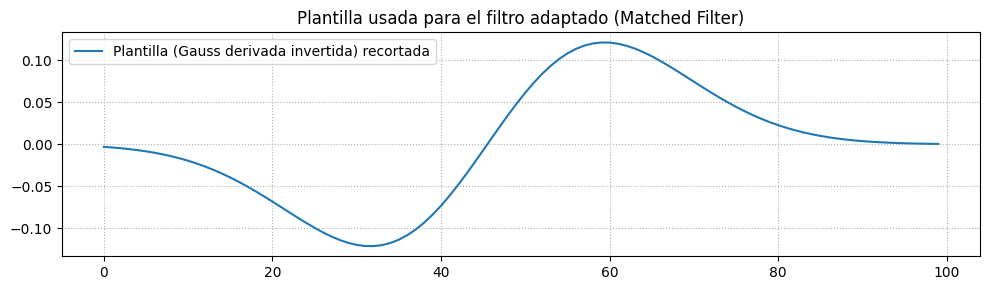

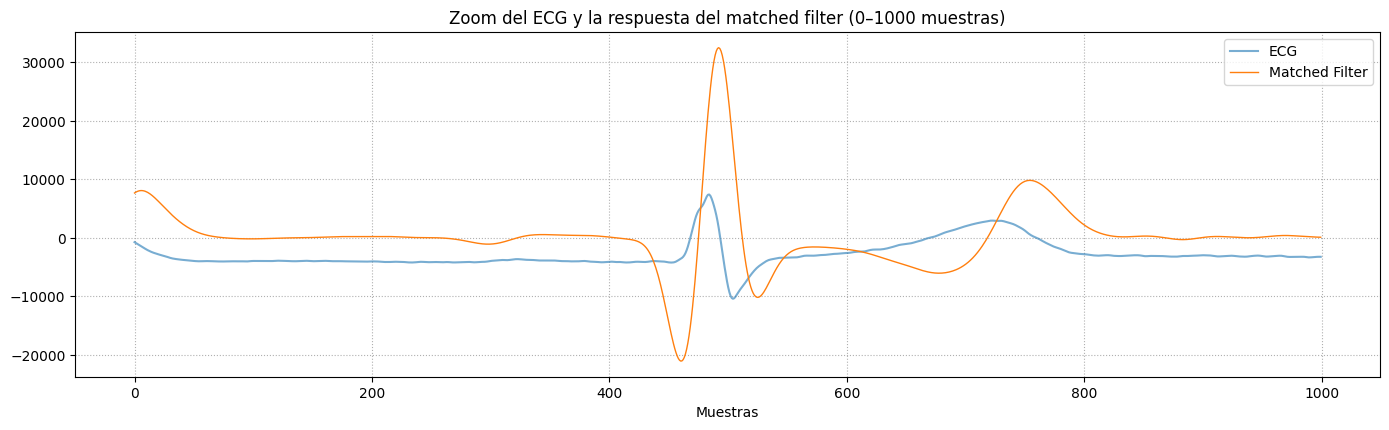

In [15]:
maximos = mat_struct['qrs_detections'].flatten()

QRS = 140
t = np.linspace(-1, 1, QRS)
sigma = 0.2
gauss_derivada = -t * np.exp(-t**2 / (2*sigma**2))


#tengo que mover porque el pico de la gaussiana no esta clavada en el medio de mi # de muestras
max_gauss = np.argmax(gauss_derivada)
mover = QRS//2 - max_gauss
gauss_centrada = np.roll(gauss_derivada, mover)

##doy vuelta mi patron para convolcionar 
h = gauss_centrada[::-1]   
h = h[10:110]

y = np.convolve(ecg_one_lead, h, mode='same')


###################################
# Gráfico de la plantilla
###################################

plt.figure(figsize=(10,3))
plt.plot(h, label="Plantilla (Gauss derivada invertida) recortada")
plt.title("Plantilla usada para el filtro adaptado (Matched Filter)")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()
###################################
# Gráfico de la convolución
###################################

plt.figure(figsize=(14,8))

# Panel 2: zoom a 1000 muestras
plt.subplot(2,1,2)
plt.plot(ecg_one_lead[0:1000], label="ECG", alpha=0.6)
plt.plot(y[0:1000], label="Matched Filter", linewidth=1)
plt.title("Zoom del ECG y la respuesta del matched filter (0–1000 muestras)")
plt.xlabel("Muestras")
plt.grid(True, ls=":")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


En esta señal $y(n)$ los QRS aparecen como picos prominentes. Para detectarlos se utilizó *find_peaks* una función de scipy.signal, imponiendo:
- distance = QRS (140 fue el valor que utilice) → La separacion fisiológicamente válida
- prominence = 0.39 → elimina falsos positivos por ruido

#### Evaluación del desempeño

Se compararon las detecciones con las anotaciones de referencia proporcionadas por la cátedra, construyendo una matriz de confusión que contabiliza verdaderos positivos (TP), falsos positivos (FP) y falsos negativos (FN). A partir de ello se calcularon:
- Precisión
- Sensibilidad (Recall)
- F1-score
Estos indicadores permiten evaluar de forma objetiva la calidad del detector frente a ruido y variabilidad fisiológica.

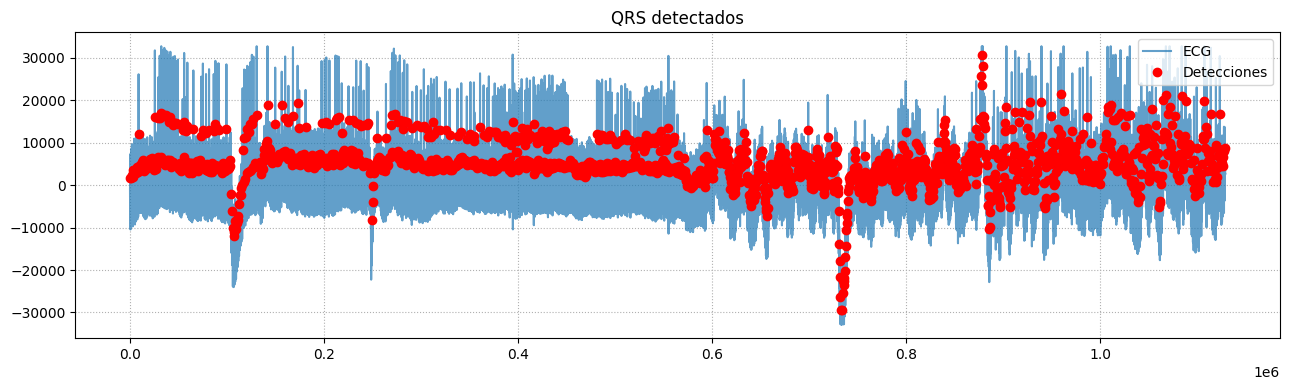


==== MATRIZ DE CONFUSIÓN ====

           Predicho
           Sí     No
Real Sí:  [1900     3]
Real No:  [   2     - ]

==== MÉTRICAS ====
Precisión     : 99.89%
Sensibilidad  : 99.84%
F1-score      : 99.87%



In [16]:
peaks, _ = signal.find_peaks(y,distance=QRS, prominence=np.max(y)*0.39)

###################################
# Matriz de Confusión
###################################

def matriz_confusion_qrs(peaks, maximos, tolerancia_ms=80, fs=1000):
    peaks = np.array(peaks)
    maximos = np.array(maximos)

    tol = int(tolerancia_ms * fs / 1000)

    TP = FP = FN = 0
    emp_peaks = np.zeros(len(peaks), dtype=bool)
    emp_ref   = np.zeros(len(maximos), dtype=bool)

    for i, det in enumerate(peaks):
        diffs = np.abs(maximos - det)
        j = np.argmin(diffs)
        if diffs[j] <= tol and not emp_ref[j]:
            TP += 1
            emp_peaks[i] = True
            emp_ref[j] = True

    FP = np.sum(~emp_peaks)
    FN = np.sum(~emp_ref)

    matriz = np.array([
        [TP, FP],
        [FN, 0]
    ])

    return matriz, TP, FP, FN


matriz, TP, FP, FN = matriz_confusion_qrs(peaks, maximos)

# Métricas
precision = TP / (TP + FP) if TP + FP > 0 else 0
recall    = TP / (TP + FN) if TP + FN > 0 else 0
f1        = 2 * (precision*recall) / (precision + recall) if precision + recall > 0 else 0

###################################
# Gráfico final de detecciones sobre ECG
###################################

plt.figure(figsize=(13,4))
plt.plot(ecg_one_lead, label="ECG", alpha=0.7)
plt.plot(peaks, ecg_one_lead[peaks], "ro", label="Detecciones")
plt.title("QRS detectados")
plt.grid(True, ls=':')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

###################################
# Impresión prolija de resultados
###################################

print("\n==== MATRIZ DE CONFUSIÓN ====\n")
print("           Predicho")
print("           Sí     No")
print(f"Real Sí:  [{TP:4d}  {FN:4d}]")
print(f"Real No:  [{FP:4d}     - ]")

print("\n==== MÉTRICAS ====")
print(f"Precisión     : {precision*100:5.2f}%")
print(f"Sensibilidad  : {recall*100:5.2f}%")
print(f"F1-score      : {f1*100:5.2f}%\n")

# Conclusión

En esta práctica se aplicaron distintas técnicas no lineales para el procesamiento de un ECG real, con el objetivo de corregir la deriva de la línea de base y lograr una detección robusta de complejos QRS. El filtrado por mediana mostró ser un método simple y efectivo para suprimir variaciones lentas sin alterar la morfología del latido, preservando adecuadamente los complejos QRS aun en presencia de ruido moderado. Por su parte, la corrección mediante spline cúbico permitió obtener una estimación más suave y continua del nivel isoeléctrico, brindando una reconstrucción precisa de la tendencia lenta siempre que los nodos se seleccionen en regiones fisiológicamente estables.

Finalmente, el filtro adaptado basado en la correlación con una plantilla derivada de gaussiana proporcionó un mecanismo altamente eficaz para la identificación de QRS, alcanzando niveles prácticamente óptimos de precisión y sensibilidad. Su capacidad para resaltar la energía del complejo ventricular permitió minimizar tanto falsos positivos como falsos negativos.

En conjunto, los resultados muestran que la combinación de métodos no lineales para la corrección de la línea de base y técnicas de correlación para la detección de QRS constituye una estrategia sólida y confiable para el análisis de ECG en condiciones reales de adquisición.

## Autoevaluacion

*Indicar una opción (marcada con negrita):*

1. **Resolví la tarea con seguridad**
2. Resolví la tarea, pero tengo dudas
3. Resolví la tarea,pero no entendí bien
4. No pude resolverla y no entendí


Responder:

*¿Qué aprendiste al hacer esta tarea?*

En esta TS aprendimos a detectar picos mediante la correlacion entre la señal y un patron conocido. Ademas de poder filtrar la señal como veniamos haciendo anteriormente con los filtros lineales. Aca pudimos ser un poco mas precisos con un lugar en particular, como la linea de base. 

*¿Qué te quedó claro? ¿Qué te sigue costando?*

Se comprendio que el uso exacto de la ventana en la mediana, el lugar mas aporximado de la ubicacion de los nodos para el spline,  la decision de utilizar una gaussiana como un patron parecido al QRS del ECG y la convolucion para encontrar mayor diferencia de energia entre los picos R versus los picos de P y T, te llevan a una resolucion del problema mas precisa. 

*Indicar si se utilizó IA:*

**Sí, usé chatGPT, Qwen, Deepseek, Gemini, otra.**
No usé IA.
*En caso afirmativo, indicar una opción o varias:*

Escritura

Código

**Conceptos teorícos**

**Gráficos**

**Conclusiones** 